<a href="https://colab.research.google.com/github/sofianna-e/DeliveriesEKPA/blob/main/IDS_excercise.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_8 (Dense)                 │ (None, 256)            │         6,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 48,003 (187.51 KB)

 Trainable params: 48,003 (187.51 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/40
164/164 - 2s - 13ms/step - accuracy: 0.7197 - loss: 0.7074 - val_accuracy: 0.8310 - val_loss: 0.5162
Epoch 2/40
164/164 - 1s - 3ms/step - accuracy: 0.8353 - loss: 0.4906 - val_accuracy: 0.8671 - val_loss: 0.4411
Epoch 3/40
164/164 - 1s - 3ms/step - accuracy: 0.8699 - loss: 0.4311 - val_accuracy: 0.8898 - val_loss: 0.3915
Epoch 4/40
164/164 - 1s - 5ms/step - accuracy: 0.8857 - loss: 0.3994 - val_accuracy: 0.8804 - val_loss: 0.4064
Epoch 5/40
164/164 - 1s - 8ms/step - accuracy: 0.8918 - loss: 0.3857 - val_accuracy: 0.8958 - val_loss: 0.3726
Epoch 6/40
164/164 - 1s - 4ms/step - accuracy: 0.8982 - loss: 0.3737 - val_accuracy: 0.9092 - val_loss: 0.3494
Epoch 7/40
164/164 - 1s - 3ms/step - accuracy: 0.9025 - loss: 0.3632 - val_accuracy: 0.9172 - val_loss: 0.3425
Epoch 8/40
164/164 - 1s - 4ms/step - accuracy: 0.9024 - loss: 0.3606 - val_accuracy: 0.9045 - val_loss: 0.3495
Epoch 9/40
164/164 - 1s - 3ms/step - accuracy: 0.9032 - loss: 0.3548 - val_accuracy: 0.9051 - val_loss: 0.3532


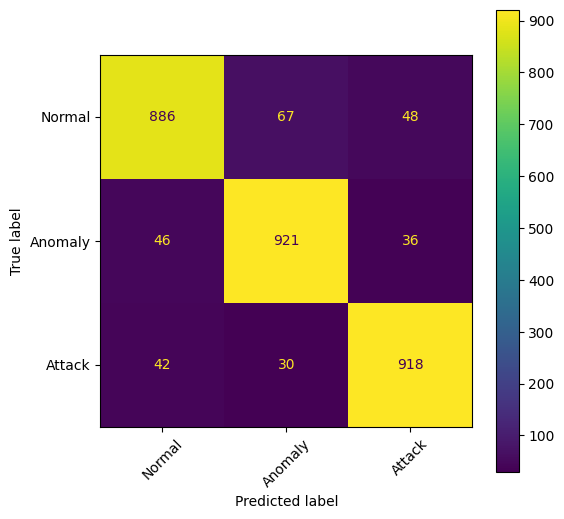

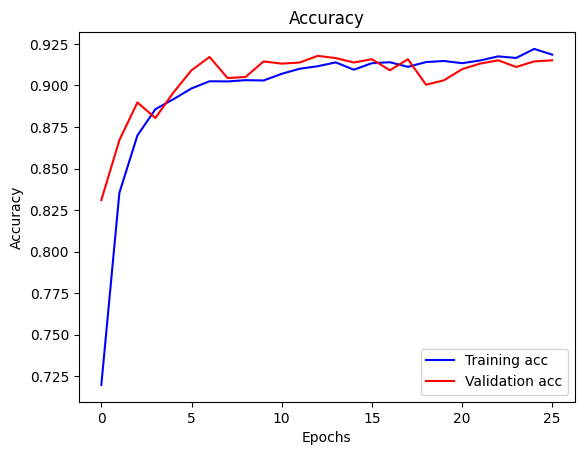

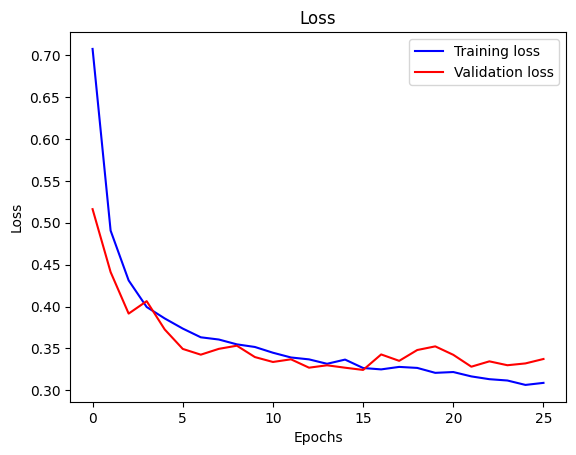

In [3]:
# ------------------------------
# Εισαγωγή βιβλιοθηκών
# ------------------------------
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.utils import class_weight
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping

# ------------------------------
# Παράμετροι
# ------------------------------
epochs = 40
batch_size = 64
nclass = 3  # Normal, Anomaly, Attack

# ------------------------------
# Φόρτωση Dataset
# ------------------------------
def load_dataset():
    url = 'https://raw.githubusercontent.com/kdemertzis/EKPA/refs/heads/main/Data/pcap_data.csv'
    data = pd.read_csv(url).to_numpy()

    X = data[:, :-1].astype('float32')
    y = data[:, -1].astype('int32')

    # Ανακάτεμα και Διαχωρισμός
    np.random.shuffle(data)
    X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, stratify=y, random_state=42)
    X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=2/3, stratify=y_temp, random_state=42)

    # Min-max normalization
    dmin = X_train.min(axis=0)
    dmax = X_train.max(axis=0)
    X_train = (X_train - dmin) / (dmax - dmin)
    X_val = (X_val - dmin) / (dmax - dmin)
    X_test = (X_test - dmin) / (dmax - dmin)

    return X_train, y_train, X_val, y_val, X_test, y_test

# ------------------------------
# Φόρτωση δεδομένων
# ------------------------------
X_train, y_train_raw, X_val, y_val_raw, X_test, y_test_raw = load_dataset()

# Μετατροπή labels σε one-hot
y_train = to_categorical(y_train_raw, nclass)
y_val   = to_categorical(y_val_raw, nclass)
y_test  = to_categorical(y_test_raw, nclass)

# ------------------------------
# Υπολογισμός κλάσεων βαρών
# ------------------------------
class_weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train_raw),
    y=y_train_raw
)
class_weights = dict(enumerate(class_weights))

# ------------------------------
# Δημιουργία μοντέλου
# ------------------------------
model = Sequential([
    Dense(256, activation='relu', input_shape=(X_train.shape[1],)),
    Dense(128, activation='relu'),
    Dense(64, activation='relu'),
    Dense(nclass, activation='softmax')
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()

# ------------------------------
# Εκπαίδευση
# ------------------------------
early_stop = EarlyStopping(monitor='val_loss', patience=10, verbose=1, mode='min')
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=epochs,
    batch_size=batch_size,
    class_weight=class_weights,
    shuffle=True,
    callbacks=[early_stop],
    verbose=2
)

# ------------------------------
# Αξιολόγηση
# ------------------------------
pred = model.predict(X_test)
pred_labels = pred.argmax(axis=-1)
y_test_labels = y_test.argmax(axis=-1)

cm = confusion_matrix(y_test_raw, pred_labels)
print("Confusion Matrix:")
print(cm)

classes = ['Normal', 'Anomaly', 'Attack']
print("\nAccuracy per class:")
for i, name in enumerate(classes):
    acc = cm[i,i]/np.sum(cm[i,:])
    print(f"{name:<8}: {acc:.4f}")

# ------------------------------
# Confusion Matrix
cmo = ConfusionMatrixDisplay(cm, display_labels=classes)
fig, ax = plt.subplots(figsize=(6,6))
cmo.plot(ax=ax, xticks_rotation=45)
plt.show()

# ------------------------------
# Accuracy & Loss
# ------------------------------
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs_range = range(len(acc))

plt.figure()
plt.plot(epochs_range, acc, 'b', label='Training acc')
plt.plot(epochs_range, val_acc, 'r', label='Validation acc')
plt.title('Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.figure()
plt.plot(epochs_range, loss, 'b', label='Training loss')
plt.plot(epochs_range, val_loss, 'r', label='Validation loss')
plt.title('Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()